In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
plt.rcParams["font.family"] = "Yu Gothic"

In [7]:
df = pd.read_excel("../data/Online Retail.xlsx")
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
df = pd.read_excel("../data/Online Retail.xlsx")
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [9]:
df.to_csv("../data/online_retail.csv", index=False)

In [10]:
df = pd.read_csv("../data/online_retail.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [11]:
df.shape


(541909, 8)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [13]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [14]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## <span style="color:green;">データの前処理</span>

In [15]:
df_clean = df.copy()

In [16]:
# 日付順にソート
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

**欠損値処理**

In [17]:
print(df_clean['CustomerID'].isna().mean())

0.249266943342886


In [18]:
# CustomerIDの欠損値がある行は全体の約25パーセントを占めるが、分析に使えないため削除する。
df_clean = df_clean.dropna(subset=["CustomerID"])
# Descriptionに関しては、分析ではStockCodeを用いるため直接扱わない。そのため欠損値補完は行わない。
print(df_clean.isnull().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [19]:
# 上の結果より、Descriptionが欠損している行はすべてCustomerIDも同様に欠損していることが推測される。
df[df["Description"].isna()][
    ["Description", "CustomerID"]
].isna().sum()

Description    1454
CustomerID     1454
dtype: int64

In [20]:
# キャンセルされた取引を削除 
df_clean = df_clean[
    (~df_clean["InvoiceNo"].astype(str).str.startswith("C"))
    & (df_clean["Quantity"] > 0)
    & (df_clean["UnitPrice"] > 0)
]
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,397884.000000,397884,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023,3.116488,15294.423453
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,179.331775,NaN,22.097877,1713.141560


### RFM分析 
Recency:最終購入日からの経過日数。  
Frequency:購入頻度。購入回数。  
Monetary:購入金額の総額。  

In [21]:
# 基準とする日付
basis_InvoiceDate = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean['UnitPrice']
# Recency,Frequency,MonetaryをCustomerIDごとに求める
recency = df_clean.groupby("CustomerID")["InvoiceDate"].max()
frequency = df_clean.groupby("CustomerID")["InvoiceNo"].nunique()
monetary = df_clean.groupby("CustomerID")["TotalPrice"].sum()

rfm = pd.DataFrame(
    {
        "Recency": (basis_InvoiceDate - recency).dt.days,
        "Frequency": frequency,
        "Monetary": monetary
    }
).reset_index()
rfm

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
...,...,...,...,...
4333,18280.0,278,1,180.60
4334,18281.0,181,1,80.82
4335,18282.0,8,2,178.05
4336,18283.0,4,16,2094.88


In [22]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


### ヒストグラムで表示

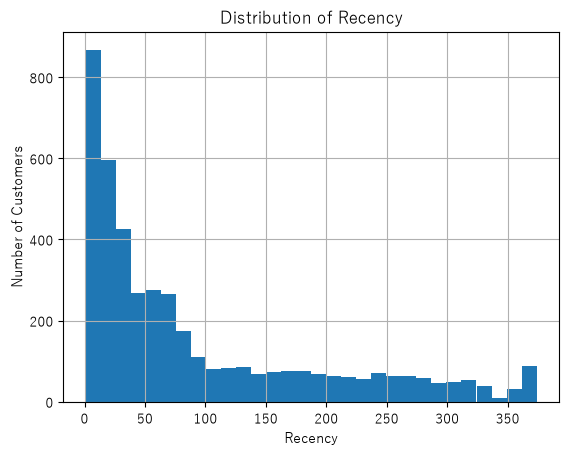

In [23]:
rfm["Recency"].hist(bins = 30)
plt.title("Distribution of Recency")
plt.xlabel("Recency")
plt.ylabel("Number of Customers")
plt.show()

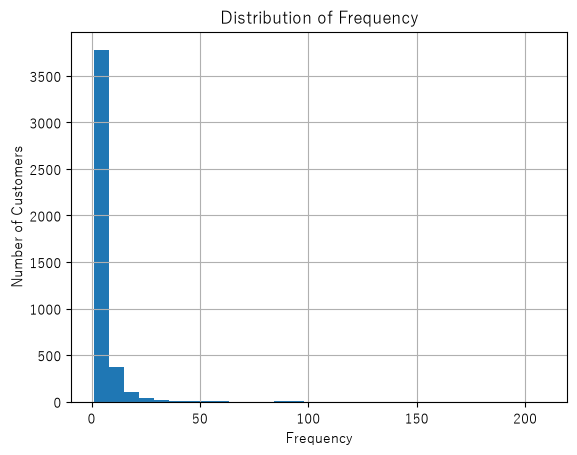

In [24]:
rfm["Frequency"].hist(bins = 30)
plt.title("Distribution of Frequency")
plt.xlabel("Frequency")
plt.ylabel("Number of Customers")
plt.show()

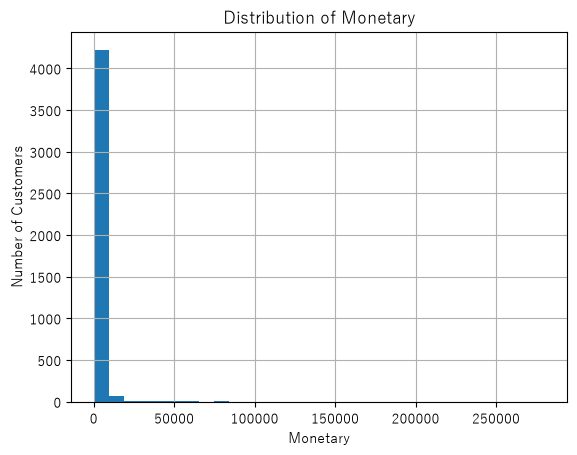

In [25]:
rfm["Monetary"].hist(bins=30)
plt.title("Distribution of Monetary")
plt.xlabel("Monetary")
plt.ylabel("Number of Customers")
plt.show()

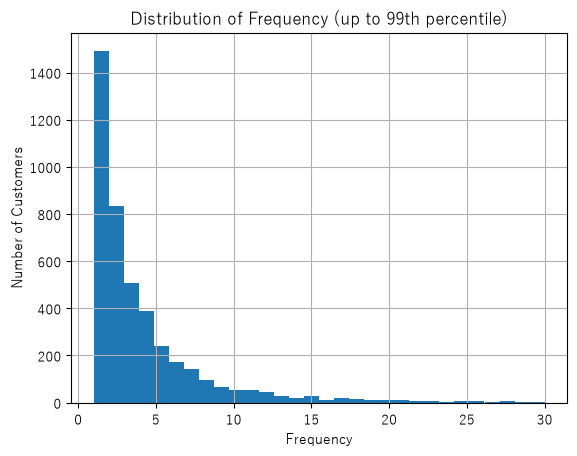

In [26]:
# わかりやすくするために上位1パーセントを除外
frequency_limit = rfm["Frequency"].quantile(0.99)
rfm[rfm["Frequency"] <= frequency_limit]["Frequency"].hist(bins = 30)
plt.title("Distribution of Frequency (up to 99th percentile)")
plt.xlabel("Frequency")
plt.ylabel("Number of Customers")
plt.show()

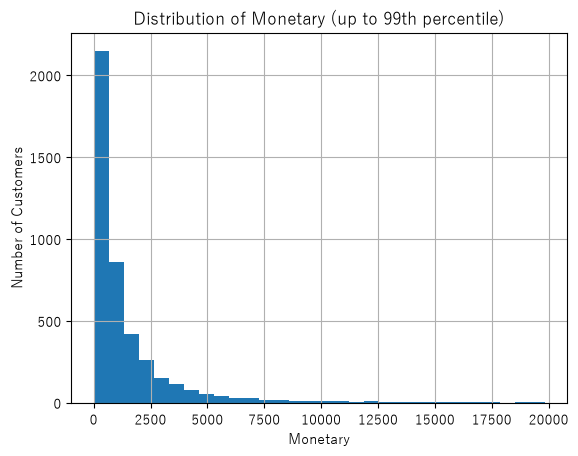

In [27]:
# わかりやすくするために上位1パーセントを除外
monetary_limit = rfm["Monetary"].quantile(0.99)

rfm[rfm["Monetary"] <= monetary_limit]["Monetary"].hist(bins=30)

plt.title("Distribution of Monetary (up to 99th percentile)")
plt.xlabel("Monetary")
plt.ylabel("Number of Customers")
plt.show()

In [28]:
# 次にスコアの割り当てを決める。
# データの分布が極端に偏っているため、cutメソッドではなく、qcutメソッドを使う
# Recencyのみ小さいほどいいためラベルが逆
rfm["R_score"] = pd.qcut(
    rfm["Recency"],
    3,
    labels=[3,2,1]
)
# 四分位数が重複しないようにrankメソッドで購入回数を順位に変換
rfm["F_score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    3,
    labels=[1,2,3]
)

rfm["M_score"] = pd.qcut(
    rfm["Monetary"],
    3,
    labels=[1,2,3]
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score
0,12346.0,326,1,77183.60,1,1,3
1,12347.0,2,7,4310.00,3,3,3
2,12348.0,75,4,1797.24,2,2,3
3,12349.0,19,1,1757.55,3,1,3
4,12350.0,310,1,334.40,1,1,1


In [29]:
# 次に先ほどもとめたスコアを用いて９つのグループに分類する
segment_map = {
    (3, 3): "優良",
    (3, 2): "優良候補",
    (3, 1): "新規",

    (2, 3): "警戒",
    (2, 2): "注意",
    (2, 1): "休眠傾向",

    (1, 3): "過去最良",
    (1, 2): "過去候補",
    (1, 1): "休眠"
}

In [30]:
def assign_segment(row):
    key = (
        int(row["R_score"]),
        int(row["F_score"])
    )
    return segment_map[key]


In [ ]:
# 各顧客データを分類し列を追加
rfm["Segment"] = rfm.apply(
    assign_segment,
    axis=1
)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,Segment
0,12346.0,326,1,77183.60,1,1,3,休眠
1,12347.0,2,7,4310.00,3,3,3,優良
2,12348.0,75,4,1797.24,2,2,3,注意
3,12349.0,19,1,1757.55,3,1,3,新規
4,12350.0,310,1,334.40,1,1,1,休眠


In [32]:
segment_count = rfm["Segment"].value_counts()
segment_count

Segment
優良      870
休眠      819
注意      531
過去候補    490
休眠傾向    458
警戒      440
優良候補    425
新規      169
過去最良    136
Name: count, dtype: int64

In [ ]:
# セグメントごとの顧客比率
segment_ratio = (
    rfm["Segment"].value_counts(normalize=True).mul(100).round(1)
)
segment_ratio

Segment
優良      20.1
休眠      18.9
注意      12.2
過去候補    11.3
休眠傾向    10.6
警戒      10.1
優良候補     9.8
新規       3.9
過去最良     3.1
Name: proportion, dtype: float64

In [34]:
ratio_table = pd.crosstab(
    rfm["R_score"],
    rfm["F_score"],
    normalize="all"
) * 100

In [ ]:
# 各セグメントの顧客比率をテーブルで表示
ratio_table = ratio_table.reindex(
    index = [3,2,1],
    columns = [3,2,1]
)
ratio_table

F_score,3,2,1
R_score,,,
3,20.055325,9.797142,3.895805
2,10.142923,12.240664,10.557861
1,3.135085,11.295528,18.879668


In [ ]:
# Monetaryの平均表
monetary_table = pd.pivot_table(
    rfm,
    index="R_score",
    columns="F_score",
    values="Monetary",
    aggfunc="mean",
    observed=True
)

In [37]:
monetary_table = monetary_table.reindex(
    index=[3, 2, 1],
    columns=[3, 2, 1]
)

monetary_table

F_score,3,2,1
R_score,,,
3,6184.598862,1314.430612,324.564201
2,2688.958230,953.686744,424.474172
1,1726.564191,915.764900,427.138645


In [38]:
segment_name_talble = [
    ["優良", "優良候補", "新規"],
    ["警戒", "注意", "休眠傾向"],
    ["過去最良", "過去候補", "休眠"]
]

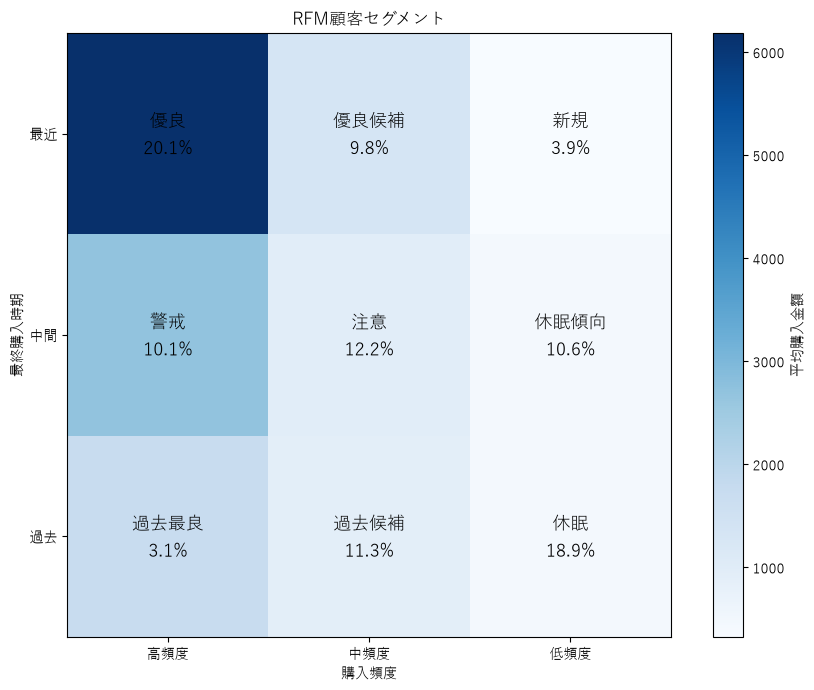

In [ ]:
# ビジュアル化
fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(
    monetary_table.values,
    cmap = "Blues"
)

for i in range(3):
    for j in range(3):
        segment_name = segment_name_talble[i][j]
        ratio = ratio_table.iloc[i, j]
        text = f"{segment_name}\n{ratio:.1f}%"

        ax.text(
            j,
            i,
            text,
            ha="center",
            va="center",
            fontsize = 13
        )


ax.set_xticks([0, 1, 2])
ax.set_xticklabels(
    ["高頻度", "中頻度", "低頻度"]
)

ax.set_yticks([0, 1, 2])
ax.set_yticklabels(
    ["最近", "中間", "過去"]
)

ax.set_xlabel("購入頻度")
ax.set_ylabel("最終購入時期")
ax.set_title("RFM顧客セグメント")

colorbar = plt.colorbar(
    image,
    ax=ax
)

colorbar.set_label("平均購入金額")

plt.tight_layout()
plt.show()